This notebooks serves is exploratory to create the cumulative precipitation plot

In [44]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [45]:
# ----------- Paths ---------------------
events_dir = Path("/data0/hernanqd/plots_code/skagit_basin_de/multi_product_bulk_bias/outputs/4_clean_bias_table.csv")

In [46]:
events_df = pd.read_csv(events_dir)
events_df

,date,ar_scale,discharge_cfs,prism_3d_tot,daymet_3d_tot,pnnl_3d_tot,conus_3d_tot,ucla_3d_tot,gridmet_3d_tot,hrrr_3d_tot
0,1981-01-08,1.0,17800,0.689389,2.347281,1.677131,0.399435,0.594715,2.789105,NaN
1,1981-01-09,1.0,17600,1.909839,2.850853,8.991936,2.430993,9.246622,3.156809,NaN
2,1981-01-11,0.0,15100,2.103829,0.891865,8.373150,2.430919,9.197422,0.476459,NaN
3,1981-01-18,3.0,12900,6.131138,13.520407,21.460979,11.162983,16.286510,8.262257,NaN
4,1981-01-19,3.0,12600,11.069244,14.951836,36.435169,12.473938,20.061474,8.737743,NaN
...,...,...,...,...,...,...,...,...,...,...
4534,2025-12-17,1.0,78700,135.407013,NaN,NaN,NaN,NaN,NaN,NaN
4535,2025-12-18,1.0,68600,142.060089,NaN,NaN,NaN,NaN,NaN,NaN
4536,2025-12-19,1.0,59000,111.416527,NaN,NaN,NaN,NaN,NaN,NaN
4537,2025-12-21,0.0,45800,71.890732,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
# Find AR events (ar_scale != 0) with highest pnnl_3d_tot
ar_events = events_df[events_df['ar_scale'] != 0].copy()
ar_events_sorted = ar_events.dropna(subset=['pnnl_3d_tot']).sort_values('pnnl_3d_tot', ascending=False)
print(f"Top AR events by PNNL 3-day total precipitation:")
print(ar_events_sorted[['date', 'ar_scale', 'pnnl_3d_tot', 'discharge_cfs']].head(10))

Top AR events by PNNL 3-day total precipitation:
            date  ar_scale  pnnl_3d_tot  discharge_cfs
121   1982-02-15       3.0   207.296417          53900
513   1986-02-25       4.0   200.783997          60900
204   1983-01-10       2.0   198.347717          46600
1812  1998-11-15       4.0   185.240082          33900
122   1982-02-16       3.0   182.385880          53900
992   1990-11-24       5.0   181.928574          97200
1432  1995-02-19       4.0   179.863708          46200
2314  2003-11-19       4.0   178.177979          64500
2827  2009-01-08       4.0   174.095062          72900
397   1984-11-03       2.0   171.640015          27400


In [48]:
# Find AR events (ar_scale != 0) with highest prism_3d_tot
ar_events = events_df[events_df['ar_scale'] != 0].copy()
ar_events_sorted = ar_events.dropna(subset=['prism_3d_tot']).sort_values('prism_3d_tot', ascending=False)
print(f"Top AR events by PRISM 3-day total precipitation:")
print(ar_events_sorted[['date', 'ar_scale', 'prism_3d_tot', 'discharge_cfs']].head(20))

Top AR events by PRISM 3-day total precipitation:
            date  ar_scale  prism_3d_tot  discharge_cfs
889   1989-11-09       4.0    250.212158          50600
987   1990-11-09       4.0    249.746765          36700
992   1990-11-24       5.0    240.166336          97200
2827  2009-01-08       4.0    237.971466          72900
4528  2025-12-11       4.0    237.468063         102000
993   1990-11-25       5.0    233.456451         142000
3984  2020-01-03       2.0    224.112625          21800
2314  2003-11-19       4.0    205.660309          64500
1495  1995-11-10       2.0    201.195114          48800
2440  2005-01-18       4.0    185.706116          44500
4529  2025-12-12       4.0    180.965622         112000
121   1982-02-15       3.0    179.493713          53900
508   1986-01-19       4.0    174.927444          63400
204   1983-01-10       2.0    174.121338          46600
122   1982-02-16       3.0    170.462814          53900
1494  1995-11-08       3.0    170.154877          4840

In [49]:
import os
import xarray as xr
import numpy as np
import geopandas as gpd
import regionmask
from pathlib import Path

VAULT_DIR = "/data0/skagit_met/data_transfer/data"
BASE_DIR = "/data0/hernanqd/plots_code/skagit_basin_de"
HUC8_GEO = os.path.join(BASE_DIR, "data/GIS/SkagitSubBasin_HUC8.geojson")

def load_regions():
    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    return gdf

def get_mask(gdf, lon, lat):
    mask = regionmask.mask_3D_geopandas(gdf, lon, lat)
    region_indices = []
    for r in ["Upper Skagit", "Sauk", "Lower Skagit"]:
        idx = gdf[gdf["Name"].str.contains(r, case=False)].index[0]
        region_indices.append(idx)
    return mask.sel(region=region_indices)

def calculate_basin_mean(da, mask_2d):
    data = da.values
    mask = mask_2d.values if hasattr(mask_2d, 'values') else mask_2d
    if data.ndim == 3:
        time_steps = data.shape[0]
        data_flat = data.reshape(time_steps, -1)
        mask_flat = mask.flatten()
        mask_idx = mask_flat > 0
        if mask_idx.any():
            mean_vals = np.nanmean(data_flat[:, mask_idx], axis=1)
        else:
            mean_vals = np.full(time_steps, np.nan)
        time_coord = da.time.values if 'time' in da.coords else range(time_steps)
        return pd.Series(mean_vals, index=pd.to_datetime(time_coord))
    elif data.ndim == 2:
        data_flat = data.flatten()
        mask_flat = mask.flatten()
        mask_idx = mask_flat > 0
        if mask_idx.any():
            mean_val = np.nanmean(data_flat[mask_idx])
        else:
            mean_val = np.nan
        return mean_val
    else:
        raise ValueError(f"Unexpected data dimensions: {data.ndim}")

def get_decade_folder(year: int) -> str:
    start_decade = (year // 10) * 10
    if start_decade == 1980 and year > 1980: return "1981-1990"
    if year % 10 == 0 and year > 1980: return f"{start_decade-9}-{start_decade}"
    if start_decade % 10 == 0: return f"{start_decade+1}-{start_decade+10}"
    return f"{start_decade}-{(year//10)*10+9}"

def get_ornl_zarr(year):
    if 1981 <= year <= 2011:
        p = os.path.join(VAULT_DIR, "climate_sets/1981_2011_ORNL_data.zarr")
        if os.path.exists(p): return p
    p1 = os.path.join(VAULT_DIR, f"ornl/{year}_{year}_ref_DaymetV4_ORNL_data.zarr")
    if os.path.exists(p1): return p1
    p2 = os.path.join(VAULT_DIR, f"DaymetV4/{year}_{year}_ORNL_data.zarr")
    if os.path.exists(p2): return p2
    return None

def extract_event_window(event_date, products_to_extract=['prism', 'pnnl', 'daymet', 'conus', 'ucla', 'gridmet']):
    """Extract 8-day precipitation window (T-2 to T+5) for an event"""
    
    # Create 8-day window
    window_dates = []
    for i in range(-2, 6):  # T-2 through T+5
        window_dates.append(event_date + pd.Timedelta(days=i))
    
    year = event_date.year
    results = {f'{date.strftime("%Y-%m-%d")}': {} for date in window_dates}
    
    # Pre-load masks
    gdf = load_regions()
    masks_2d = {}
    
    try:
        sample_prism = xr.open_zarr(os.path.join(VAULT_DIR, "PRISM/1991-2000/1996-01-01_1996-12-31_daily_4km_PRISM_data.zarr"), consolidated=False)
        masks_2d['PRISM'] = get_mask(gdf, sample_prism.lon, sample_prism.lat).any(dim='region')
        sample_prism.close()
    except: pass
    
    try:
        sample_geo = xr.open_dataset(os.path.join(VAULT_DIR, "PNNL/SERDP6km.geo_em.d01.nc"))
        masks_2d['PNNL'] = get_mask(gdf, sample_geo.XLONG_M.values[0], sample_geo.XLAT_M.values[0]).any(dim='region')
    except: pass
    
    try:
        sample_daymet = xr.open_zarr(os.path.join(VAULT_DIR, "DaymetV4/2019_2019_ORNL_data.zarr"))
        masks_2d['Daymet'] = get_mask(gdf, sample_daymet.lon, sample_daymet.lat).any(dim='region')
    except: pass
    
    try:
        sample_conus = xr.open_zarr(os.path.join(BASE_DIR, "data/weather_data/conus404_skagit_precip_daily_full.zarr"))
        masks_2d['CONUS404'] = get_mask(gdf, sample_conus.lon, sample_conus.lat).any(dim='region')
        sample_conus.close()
    except: pass
    
    try:
        ucla_static = xr.open_dataset(os.path.join(VAULT_DIR, "ucla_era5_d02_daily/static/wrfinput_d02_coord.nc"))
        masks_2d['UCLA'] = get_mask(gdf, ucla_static.lon2d.values, ucla_static.lat2d.values).any(dim='region')
    except: pass
    
    try:
        sample_gridmet = xr.open_zarr(os.path.join(VAULT_DIR, "gridmet/2021_daily_4km_gridMET_data.zarr"))
        masks_2d['GridMET'] = get_mask(gdf, sample_gridmet.lon, sample_gridmet.lat).any(dim='region')
    except: pass
    
    # Extract PRISM
    if 'prism' in products_to_extract:
        try:
            dec = get_decade_folder(year)
            prism_path_4k = os.path.join(VAULT_DIR, "PRISM", dec, f"{year}-01-01_{year}-12-31_daily_4km_PRISM_data.zarr")
            prism_path_800 = os.path.join(VAULT_DIR, "prism_ppt_800m", f"{year}-01-01_{year}-12-31_daily_800m_PRISM_data.zarr")
            prism_path = prism_path_4k if os.path.exists(prism_path_4k) else prism_path_800
            if os.path.exists(prism_path):
                ds = xr.open_zarr(prism_path, consolidated=False)
                ds['time'] = pd.to_datetime(ds.time.values).normalize()
                da = ds['ppt'].sel(time=window_dates, method='nearest')
                if "800m" in prism_path:
                    m_prism = get_mask(gdf, ds.lon, ds.lat).any(dim='region')
                else:
                    m_prism = masks_2d.get('PRISM')
                if m_prism is not None:
                    prism_daily = calculate_basin_mean(da, m_prism)
                    prism_daily.index = prism_daily.index.normalize()
                    prism_daily = prism_daily[~prism_daily.index.duplicated(keep='first')]
                    for date in window_dates:
                        normalized_date = date.normalize()
                        if normalized_date in prism_daily.index:
                            val = prism_daily[normalized_date]
                            results[f'{date.strftime("%Y-%m-%d")}']['prism'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
                ds.close()
        except Exception as e:
            print(f"Error loading PRISM for {event_date.strftime('%Y-%m-%d')}: {e}")
    
    # Extract PNNL
    if 'pnnl' in products_to_extract and year <= 2020:
        try:
            pnnl_path = os.path.join(VAULT_DIR, "PNNL/historical", str(year), f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc")
            if os.path.exists(pnnl_path):
                ds = xr.open_dataset(pnnl_path)
                hourly_dates = []
                for d in window_dates:
                    hourly_dates.extend(pd.date_range(d, d + pd.Timedelta(hours=23), freq='h'))
                available_hourly = [d for d in hourly_dates if d in ds.time.values]
                if available_hourly and 'PNNL' in masks_2d:
                    da_subset = ds['PREC_ACC_NC'].sel(time=available_hourly)
                    s_hourly = calculate_basin_mean(da_subset, masks_2d['PNNL'])
                    pnnl_daily = s_hourly.resample('1D').sum()
                    pnnl_daily.index = pnnl_daily.index.normalize()
                    for date in window_dates:
                        normalized_date = date.normalize()
                        if normalized_date in pnnl_daily.index:
                            val = pnnl_daily[normalized_date]
                            results[f'{date.strftime("%Y-%m-%d")}']['pnnl'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
                ds.close()
        except Exception as e:
            print(f"Error loading PNNL for {event_date.strftime('%Y-%m-%d')}: {e}")
    
    # Extract Daymet
    if 'daymet' in products_to_extract:
        try:
            daymet_path = get_ornl_zarr(year)
            if daymet_path:
                is_cons = (1981 <= year <= 2011)
                ds = xr.open_zarr(daymet_path, consolidated=is_cons)
                if 'day' in ds.dims: ds = ds.rename({'day': 'time'})
                ds['time'] = pd.to_datetime(ds.time.values).normalize()
                var = 'prcp' if 'prcp' in ds.data_vars else 'ppt'
                da = ds[var].sel(time=window_dates, method='nearest')
                if 'Daymet' in masks_2d:
                    daymet_daily = calculate_basin_mean(da, masks_2d['Daymet'])
                    daymet_daily.index = daymet_daily.index.normalize()
                    daymet_daily = daymet_daily[~daymet_daily.index.duplicated(keep='first')]
                    for date in window_dates:
                        normalized_date = date.normalize()
                        if normalized_date in daymet_daily.index:
                            val = daymet_daily[normalized_date]
                            results[f'{date.strftime("%Y-%m-%d")}']['daymet'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
                if not is_cons: ds.close()
        except Exception as e:
            print(f"Error loading Daymet for {event_date.strftime('%Y-%m-%d')}: {e}")
    
    # Extract CONUS404
    if 'conus' in products_to_extract:
        try:
            conus_path = os.path.join(BASE_DIR, "data/weather_data/conus404_skagit_precip_daily_full.zarr")
            if os.path.exists(conus_path):
                ds = xr.open_zarr(conus_path)
                ds['time'] = pd.to_datetime(ds.time.values).normalize()
                da = ds['precip_daily'].sel(time=window_dates, method='nearest')
                if 'CONUS404' in masks_2d:
                    conus_daily = calculate_basin_mean(da, masks_2d['CONUS404'])
                    conus_daily.index = conus_daily.index.normalize()
                    conus_daily = conus_daily[~conus_daily.index.duplicated(keep='first')]
                    for date in window_dates:
                        normalized_date = date.normalize()
                        if normalized_date in conus_daily.index:
                            val = conus_daily[normalized_date]
                            results[f'{date.strftime("%Y-%m-%d")}']['conus'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
                ds.close()
        except Exception as e:
            print(f"Error loading CONUS404 for {event_date.strftime('%Y-%m-%d')}: {e}")
    
    # Extract UCLA
    if 'ucla' in products_to_extract:
        try:
            u_paths = [
                os.path.join(VAULT_DIR, "ucla_era5_d02_daily", "prec", f"prec.daily.era5.d02.{year-1}.nc"),
                os.path.join(VAULT_DIR, "ucla_era5_d02_daily", "prec", f"prec.daily.era5.d02.{year}.nc")
            ]
            series_list = []
            for p in u_paths:
                if os.path.exists(p):
                    try:
                        ds = xr.open_dataset(p)
                        u_var = "prec" if "prec" in ds.data_vars else "pr"
                        if 'day' in ds.dims: ds = ds.rename({'day': 'time'})
                        ds['time'] = pd.to_datetime(ds.time.values).normalize()
                        available_dates = [d for d in window_dates if d in ds.time.values]
                        if available_dates and 'UCLA' in masks_2d:
                            da_subset = ds[u_var].sel(time=available_dates)
                            s = calculate_basin_mean(da_subset, masks_2d['UCLA'])
                            s.index = s.index.normalize()
                            series_list.append(s)
                        ds.close()
                    except: pass
            if series_list:
                ucla_daily = pd.concat(series_list).sort_index()
                ucla_daily = ucla_daily[~ucla_daily.index.duplicated(keep='first')]
                for date in window_dates:
                    normalized_date = date.normalize()
                    if normalized_date in ucla_daily.index:
                        val = ucla_daily[normalized_date]
                        results[f'{date.strftime("%Y-%m-%d")}']['ucla'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
        except Exception as e:
            print(f"Error loading UCLA for {event_date.strftime('%Y-%m-%d')}: {e}")
    
    # Extract GridMET
    if 'gridmet' in products_to_extract:
        try:
            gridmet_path = os.path.join(VAULT_DIR, f"gridmet/{year}_daily_4km_gridMET_data.zarr")
            if os.path.exists(gridmet_path):
                ds = xr.open_zarr(gridmet_path)
                if 'day' in ds.dims: ds = ds.rename({'day': 'time'})
                ds['time'] = pd.to_datetime(ds.time.values).normalize()
                var = 'prcp' if 'prcp' in ds.data_vars else 'precipitation_amount'
                da = ds[var].sel(time=window_dates, method='nearest')
                if 'GridMET' in masks_2d:
                    gridmet_daily = calculate_basin_mean(da, masks_2d['GridMET'])
                    gridmet_daily.index = gridmet_daily.index.normalize()
                    gridmet_daily = gridmet_daily[~gridmet_daily.index.duplicated(keep='first')]
                    for date in window_dates:
                        normalized_date = date.normalize()
                        if normalized_date in gridmet_daily.index:
                            val = gridmet_daily[normalized_date]
                            results[f'{date.strftime("%Y-%m-%d")}']['gridmet'] = float(val) if not isinstance(val, pd.Series) else float(val.iloc[0])
                ds.close()
        except Exception as e:
            print(f"Error loading GridMET for {event_date.strftime('%Y-%m-%d')}: {e}")
    
    return pd.DataFrame(results).T

In [50]:
# Get top 5 AR events by PRISM precipitation and extract 8-day windows
top_5_dates = ar_events_sorted.head(5)['date'].values
specific_date = pd.to_datetime('2021-11-15')

# Check if specific date is in top 5
if specific_date not in top_5_dates:
    events_to_extract = list(top_5_dates) + [specific_date]
else:
    events_to_extract = list(top_5_dates)

print(f"Extracting 8-day precipitation windows for {len(events_to_extract)} events...")
print(f"Events: {[pd.to_datetime(d).strftime('%Y-%m-%d') for d in events_to_extract]}")
print()

# Extract precipitation for each event - all 6 products
event_windows = {}
for event_date in events_to_extract:
    event_date = pd.to_datetime(event_date)
    print(f"Extracting data for {event_date.strftime('%Y-%m-%d')}...")
    window_df = extract_event_window(event_date, products_to_extract=['prism', 'pnnl', 'daymet', 'conus', 'ucla', 'gridmet'])
    event_windows[event_date.strftime('%Y-%m-%d')] = window_df
    print(window_df)
    print()

Extracting 8-day precipitation windows for 6 events...
Events: ['1989-11-09', '1990-11-09', '1990-11-24', '2009-01-08', '2025-12-11', '2021-11-15']

Extracting data for 1989-11-09...
                prism       pnnl     daymet      conus       ucla    gridmet
1989-11-07  38.341679  12.155368  15.490054   8.282616  12.686344   6.662840
1989-11-08  13.755898  20.174564  54.484161  39.068951  44.045055  94.313813
1989-11-09  99.057289  69.084412  61.534378  72.779770  91.135902  64.952140
1989-11-10        NaN  64.853737  33.399429  65.830162  74.195335  48.766342
1989-11-11        NaN   0.967970  18.820543  10.140420  13.558849  16.748638
1989-11-12  22.695499   7.637533   9.435579  14.839660  12.666989  17.570039
1989-11-13   4.808931   9.328237  13.364669  14.341976  18.822412  19.479572
1989-11-14  23.330698  11.134216   5.771048   6.156911   7.561420   0.998249

Extracting data for 1990-11-09...
                prism       pnnl     daymet         conus        ucla  \
1990-11-07  15.6

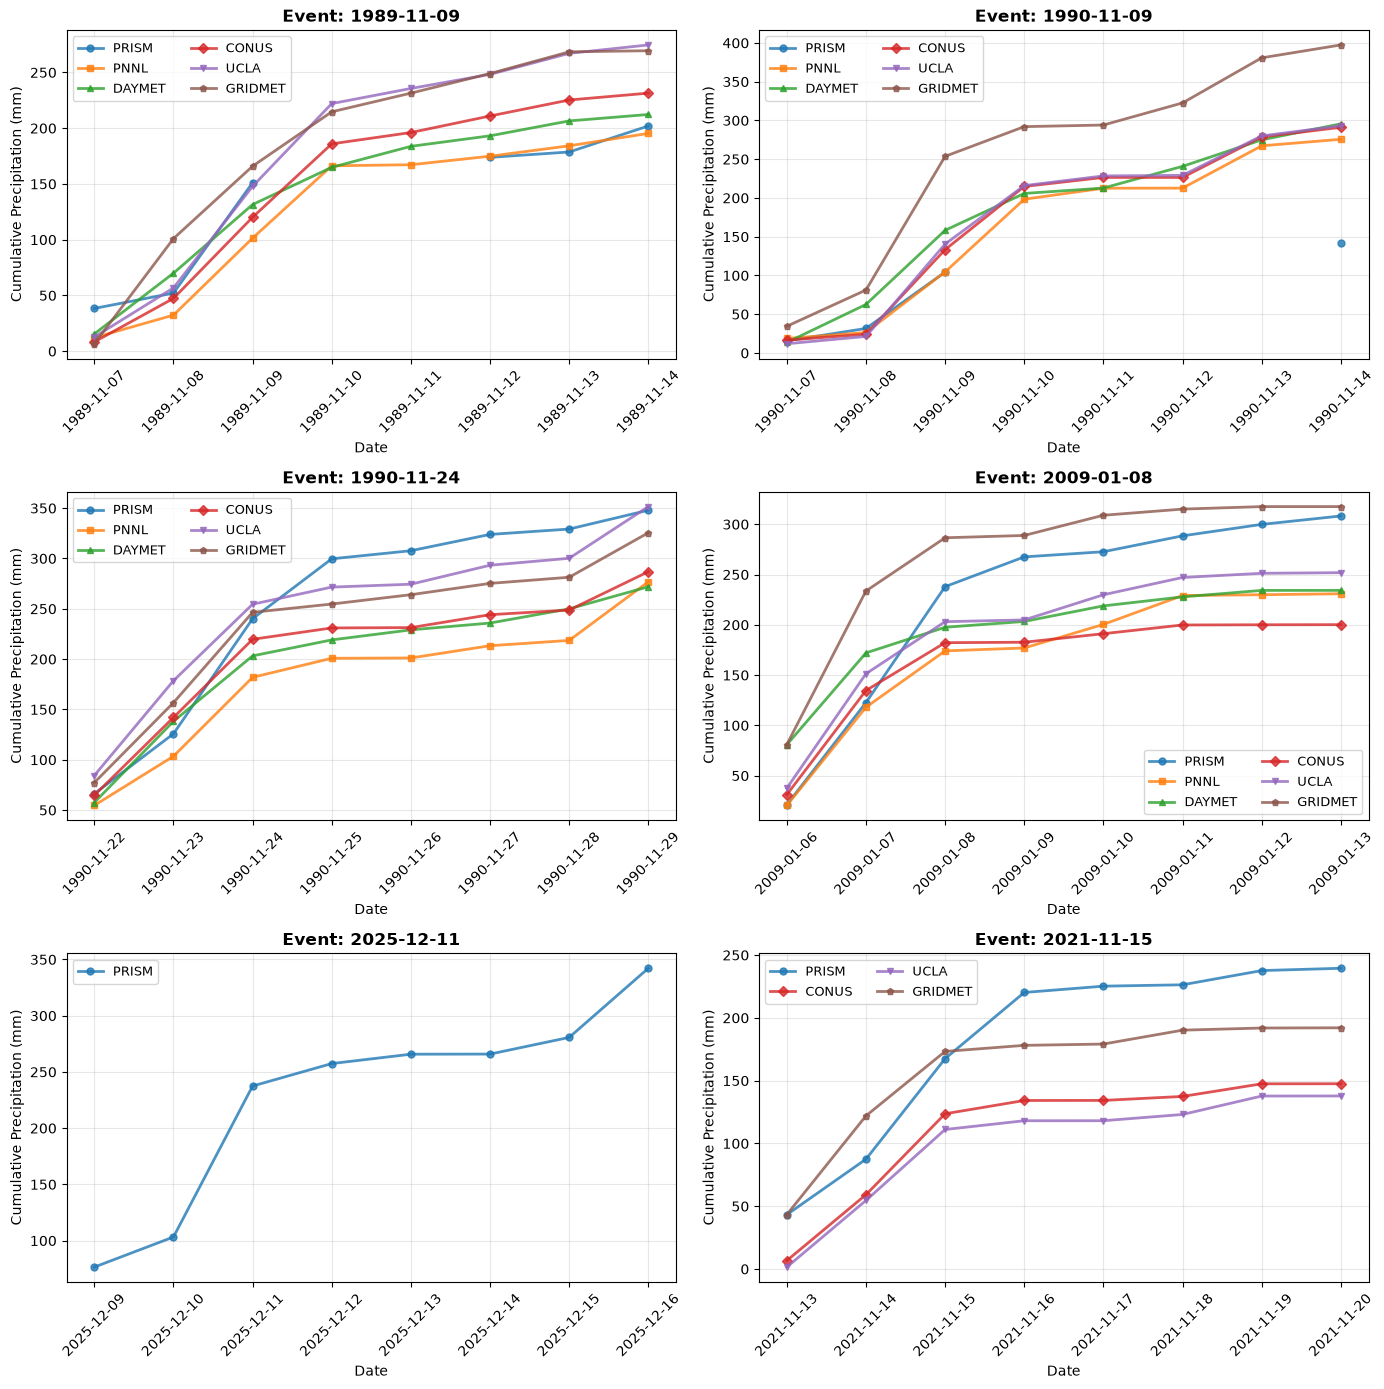

In [54]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

products = ['prism', 'pnnl', 'daymet', 'conus', 'ucla', 'gridmet']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
markers = ['o', 's', '^', 'D', 'v', 'p']

for idx, (event_date, window_df) in enumerate(event_windows.items()):
    ax = axes[idx]
    
    # Plot cumulative precipitation for each product
    for prod_idx, product in enumerate(products):
        if product in window_df.columns:
            cumsum = window_df[product].cumsum()
            ax.plot(cumsum.index, cumsum, label=product.upper(), 
                   marker=markers[prod_idx], linewidth=2, markersize=5,
                   color=colors[prod_idx], alpha=0.8)
    
    ax.set_title(f'Event: {event_date}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('Cumulative Precipitation (mm)', fontsize=10)
    ax.legend(loc='best', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()